# Model Training

## 1. Import the Dataset, required packages & Libraries:
##### 1.1 Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.

In [77]:
#Basic Imports:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

#Imports for Model building:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

#### 1.2 Import the CSV data file as pandas dataframe:

In [58]:
df = pd.read_csv('data/StudPerf.csv')

#### Show top 5 records:

In [59]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
## Adding total score column:

# df['Total Score'] = df['math score'] + df['reading score'] + df['writing score']

In [60]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# df_copy = df.drop(columns= ['reading score', 'writing score', 'math score'], axis= 1)

In [61]:
df_copy.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,Total Score
0,female,group B,bachelor's degree,standard,none,218
1,female,group C,some college,standard,completed,247
2,female,group B,master's degree,standard,none,278
3,male,group A,associate's degree,free/reduced,none,148
4,male,group C,some college,standard,none,229


### Preparing X and Y Variables:

In [62]:
X = df.drop(columns= 'math score', axis= 1)
y = df['math score']

In [63]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [64]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [65]:
#Create a Column Transformer with 3 types of Transformers:

num_features = X.select_dtypes(exclude= 'object').columns
cat_features = X.select_dtypes(include= 'object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

oh_encoder = OneHotEncoder(sparse_output= False)
num_scaler = StandardScaler()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', oh_encoder, cat_features), 
        ('StdScaler', num_scaler, num_features), 
    ]
)

In [66]:
X = preprocessor.fit_transform(X)

In [67]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

### Seperate the dataset into Train and Test data:

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [69]:
X_train.shape, X_test.shape

((800, 19), (200, 19))

### Create an Evaluation function to give all metrics after model training:

In [70]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)

    return mae, rmse, r2_square

## Model Training:

In [71]:
models = {
    'Linear Regression' : LinearRegression(), 
    'Lasso' : Lasso(), 
    'Ridge' : Ridge(), 
    'K-Neighbours Regressor' : KNeighborsRegressor(), 
    'Decision Tree' : DecisionTreeRegressor(), 
    'Random Forest Regressor' : RandomForestRegressor(), 
    'XG Boost Regressor' : XGBRegressor(), 
    'Catboost Regressor' : CatBoostRegressor(), 
    'Adaboost Regressor' : AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) #Train the model

    # Make Predictions:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Evaluate Train and Test Dataset:
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_pred_train)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_pred_test)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance for the Training Set:")
    print("Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("R2 Score: {:.4f}".format(model_train_r2))
    print("Mean Absolute Error: {:.4f}".format(model_train_mae))

    print("----------------------------------------------")

    print("Model Performance for the testing Set:")
    print("Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("R2 Score: {:.4f}".format(model_test_r2))
    print("Mean Absolute Error: {:.4f}".format(model_test_mae))
    r2_list.append(model_test_r2)

    print("="*35)
    print('\n')

Linear Regression
Model Performance for the Training Set:
Root Mean Squared Error: 5.3231
R2 Score: 0.8743
Mean Absolute Error: 4.2667
----------------------------------------------
Model Performance for the testing Set:
Root Mean Squared Error: 5.3940
R2 Score: 0.8804
Mean Absolute Error: 4.2148


Lasso
Model Performance for the Training Set:
Root Mean Squared Error: 6.5938
R2 Score: 0.8071
Mean Absolute Error: 5.2063
----------------------------------------------
Model Performance for the testing Set:
Root Mean Squared Error: 6.5197
R2 Score: 0.8253
Mean Absolute Error: 5.1579


Ridge
Model Performance for the Training Set:
Root Mean Squared Error: 5.3233
R2 Score: 0.8743
Mean Absolute Error: 4.2650
----------------------------------------------
Model Performance for the testing Set:
Root Mean Squared Error: 5.3904
R2 Score: 0.8806
Mean Absolute Error: 4.2111


K-Neighbours Regressor
Model Performance for the Training Set:
Root Mean Squared Error: 5.7079
R2 Score: 0.8555
Mean Absolut

In [72]:
pd.DataFrame(list(zip(model_list, r2_list)), columns= ['Model Name', 'R2 Score']).sort_values(by= ['R2 Score'], ascending= False)

,Model Name,R2 Score
2,Ridge,0.880593
0,Linear Regression,0.880433
7,Catboost Regressor,0.851632
5,Random Forest Regressor,0.850039
8,Adaboost Regressor,0.845029
6,XG Boost Regressor,0.827797
1,Lasso,0.825320
3,K-Neighbours Regressor,0.783813
4,Decision Tree,0.753368


## Linear Regression

In [73]:
lin_model = LinearRegression(fit_intercept= True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print("Accuracy of the model is: %.2f" %score)

Accuracy of the model is: 88.04


### Plot y_pred and y_test:

Text(0, 0.5, 'Predicted')

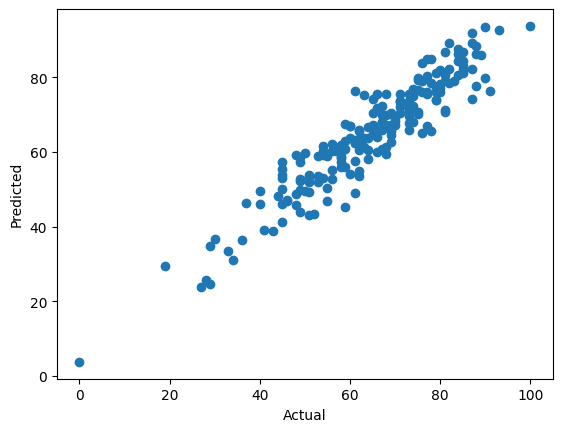

In [80]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
# plt.show()

<Axes: xlabel='math score'>

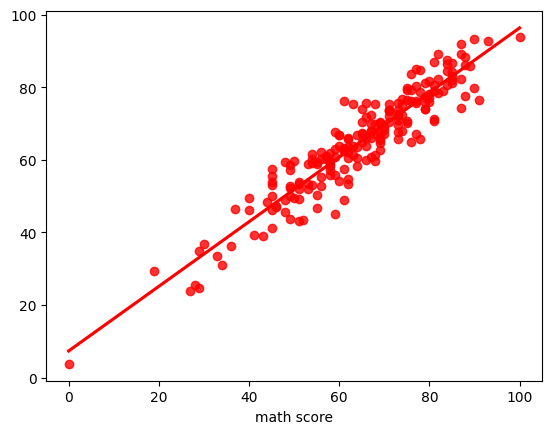

In [79]:
sns.regplot(x= y_test, y= y_pred, ci= None, color= 'red')

### Difference between Actual and Predicted Values:

In [81]:
pred_df = pd.DataFrame({'Actual Value' : y_test, 'Predicted Value' : y_pred, 'Difference' : y_test - y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
